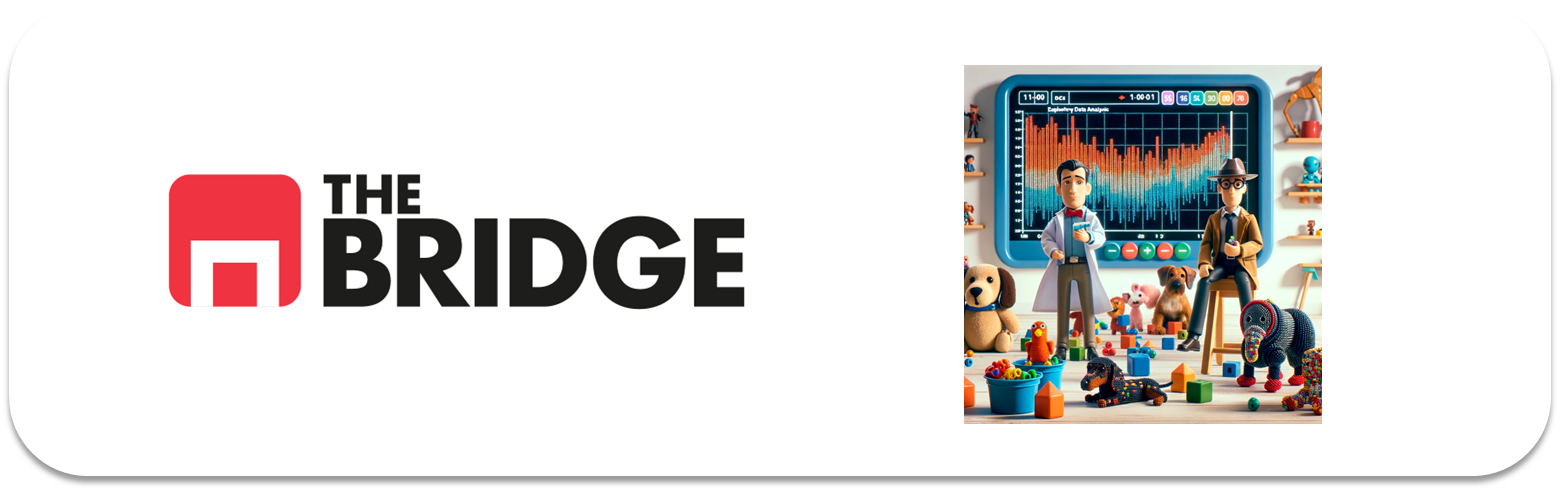

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### <mark>Mini guía</mark>

* Objetivo: Si lo tengo perfecto, si no -> lo busco

* LIMPIAR/PREPARAR LOS DATOS

* Tabla de variables: definiciones, tipificar, priorizar

* Análisis Univariante: Análisis visual y numérico
    - Categóricas: Moda, Frecuencias Absolutas y Relativas
    - Numéricas: Tendencia central (mediana, media), rangos, posición (percentiles-cuartiles, IQR, CV),distribución (histograma, densidad probabilidad)

* Análisis Bivariante: Análisis visual y numérico

    - Categórica - Categórica: Chi-2
        - Tablas de contigencia (solo para cat. con cardinalidad controlada)

    - Categórica - Numérica: 
        - Categórica es binaria: Prueba U Mann-Whitney (t-student si la variable tiene distribución normal)
        - Categórica no es binaria: ANOVA

    - Numérica - Numérica: Correlación de Pearson (Prueba estadística)
        - No hay correlación de Pearson para Categóricas
        - Binarias tampoco es correcto Pearson

    - Notas con ideas, preguntas, cosas extraordinarias

* Análisis Multivariante: A ojo, "free style"

* Haces retrospectiva -> lista de verdades/hipótesis/preguntas/suposiciones/inquietudes

    - Números

* Respuestas: MENSAJES

    - Si no hay respuesta en los datos -> ok
    - Si la respuesta es un número -> ok
    - Si la respuesta es NO -> ok

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [3]:
import pandas as pd
import seaborn as sns

pd.options.mode.copy_on_write = True # CoW por defecto a partir de Pandas 3.0.0

from bootcampviztools import pinta_distribucion_categoricas, plot_categorical_relationship_fin, plot_categorical_numerical_relationship,\
    plot_combined_graphs, grafico_dispersion_con_correlacion, plot_grouped_boxplots, plot_grouped_histograms, bubble_plot

from scipy.stats import chi2_contingency, mannwhitneyu

## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [27]:
df_titanic = pd.read_csv("./data/titanic.csv")
df_titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [28]:
df = df_titanic.copy()

### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [29]:
# Hago un drop de las columnas, sobre el eje columnas (axis = 1) y piso el df 

df = df.drop(["deck", "survived", "pclass", "embarked"], axis = 1)
df

# Da error porque lo volvió a llamar y al estar ya fijadas, dice que no la encuentra

,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone
0,male,22.0,1,0,7.2500,Third,man,True,Southampton,no,False
1,female,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False
2,female,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True
3,female,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False
4,male,35.0,0,0,8.0500,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,male,27.0,0,0,13.0000,Second,man,True,Southampton,no,True
887,female,19.0,0,0,30.0000,First,woman,False,Southampton,yes,True
888,female,NaN,1,2,23.4500,Third,woman,False,Southampton,no,False
889,male,26.0,0,0,30.0000,First,man,True,Cherbourg,yes,True


### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [30]:
df["family_members"] = df["parch"] + df["sibsp"]

In [31]:
df = df.drop(["parch", "sibsp"], axis = 1)
df

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
0,male,22.0,7.2500,Third,man,True,Southampton,no,False,1
1,female,38.0,71.2833,First,woman,False,Cherbourg,yes,False,1
2,female,26.0,7.9250,Third,woman,False,Southampton,yes,True,0
3,female,35.0,53.1000,First,woman,False,Southampton,yes,False,1
4,male,35.0,8.0500,Third,man,True,Southampton,no,True,0
...,...,...,...,...,...,...,...,...,...,...
886,male,27.0,13.0000,Second,man,True,Southampton,no,True,0
887,female,19.0,30.0000,First,woman,False,Southampton,yes,True,0
888,female,NaN,23.4500,Third,woman,False,Southampton,no,False,3
889,male,26.0,30.0000,First,man,True,Cherbourg,yes,True,0


In [32]:
df.isna().mean() # Media de nulos en cada una de las categorías el df --> hay que limpiar

sex               0.000000
age               0.198653
fare              0.000000
class             0.000000
who               0.000000
adult_male        0.000000
embark_town       0.002245
alive             0.000000
alone             0.000000
family_members    0.000000
dtype: float64

### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [33]:
moda_embark_town = df["embark_town"].mode()[0] # Cojo el índice [0] para que me dé solo el valor ç

# Guardo la moda en una variable porque si luego le pido la moda de forma dinámica, Pandas se va a quedar
# En cambio pidiéndole la moda desde una variable, no se queja 

In [34]:
df["embark_town"].value_counts(dropna=False) # Compruebo los nulos y tengo dos

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
NaN              2
Name: count, dtype: int64

In [ ]:
df["embark_town"] = df["embark_town"].fillna(moda_embark_town) # Sustituyo NaN por la moda de la columna 

In [36]:
df["embark_town"].value_counts(dropna=False) # Y ahora no tengo nulos

embark_town
Southampton    646
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [37]:
df["age"].isna()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888     True
889    False
890    False
Name: age, Length: 891, dtype: bool

In [38]:
# Columna con flags de imputación

df["age_imputed"] = df.age.isna()

In [39]:
# Imputo el valor por who en age:

# Máscaras por género

is_woman = df.who == "woman"
is_child = df.who == "child"
is_man = df.who == "man"

# Valores medianos

mediana_woman = df.loc[is_woman,"age"].median()
mediana_child = df.loc[is_child,"age"].median() # No hay chiquillos nulos, pero por si acaso...
mediana_man = df.loc[is_man,"age"].median()

# Imputamos

df.loc[is_woman & df["age_imputed"], "age"] = mediana_woman
df.loc[is_child & df["age_imputed"], "age"] = mediana_child
df.loc[is_man & df["age_imputed"], "age"] = mediana_man

In [41]:
df.isna().mean() # sin nulos

sex               0.0
age               0.0
fare              0.0
class             0.0
who               0.0
adult_male        0.0
embark_town       0.0
alive             0.0
alone             0.0
family_members    0.0
age_imputed       0.0
dtype: float64

### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

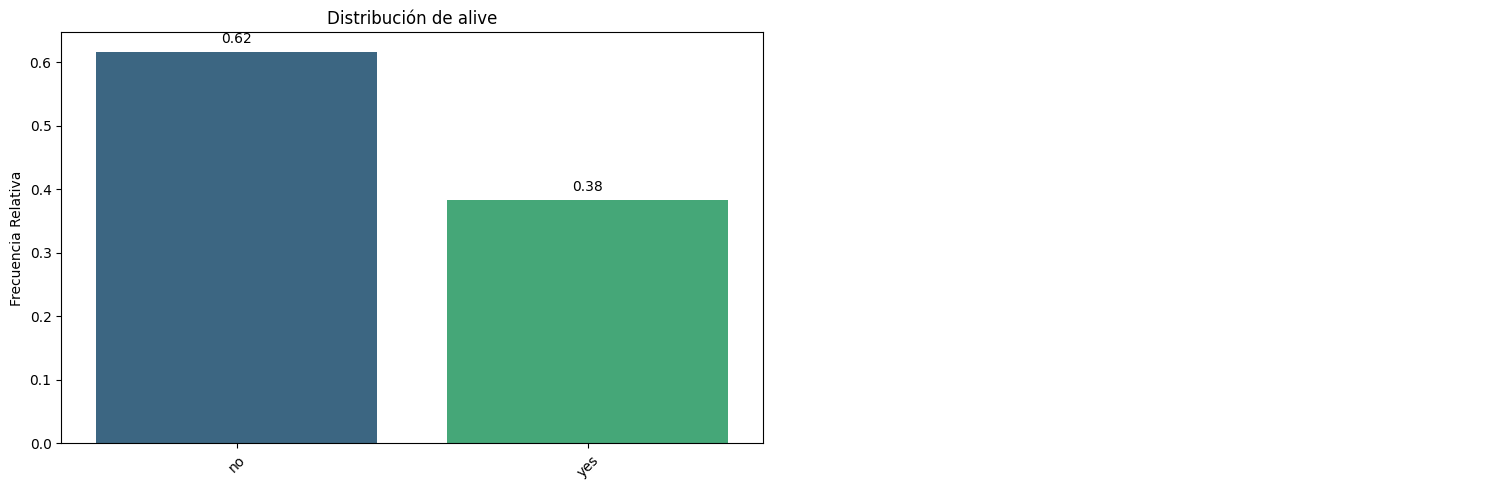

In [44]:
pinta_distribucion_categoricas(df, ["alive"], relativa= True, mostrar_valores= True) 

# Lo primero siempre es echarle un vistazo a mi categorías directoria --> en este caso alive (supervivencia o no de los pasajeros)
# Veo la frecuencia relativa de la variable para ver el reparto porcentual de supervivientes y fallecidos

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

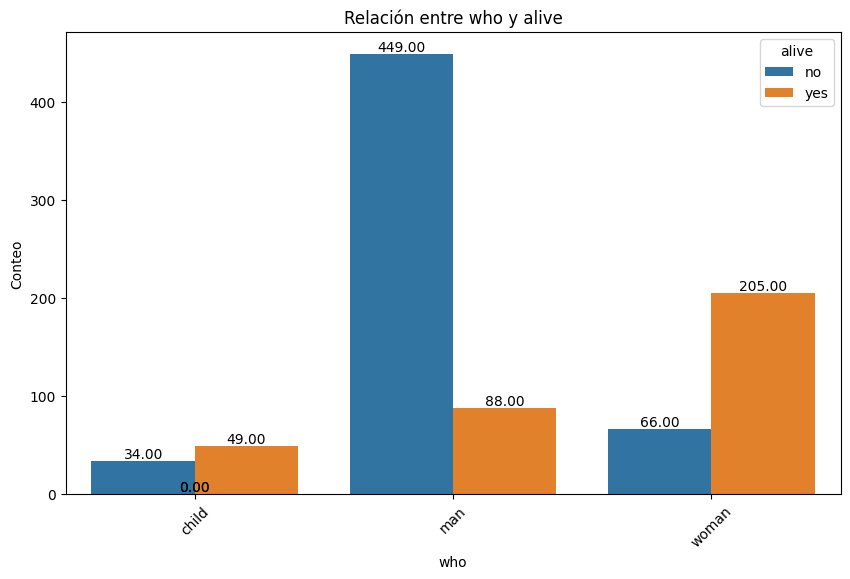

In [45]:
plot_categorical_relationship_fin(df, "who", "alive", show_values = True)

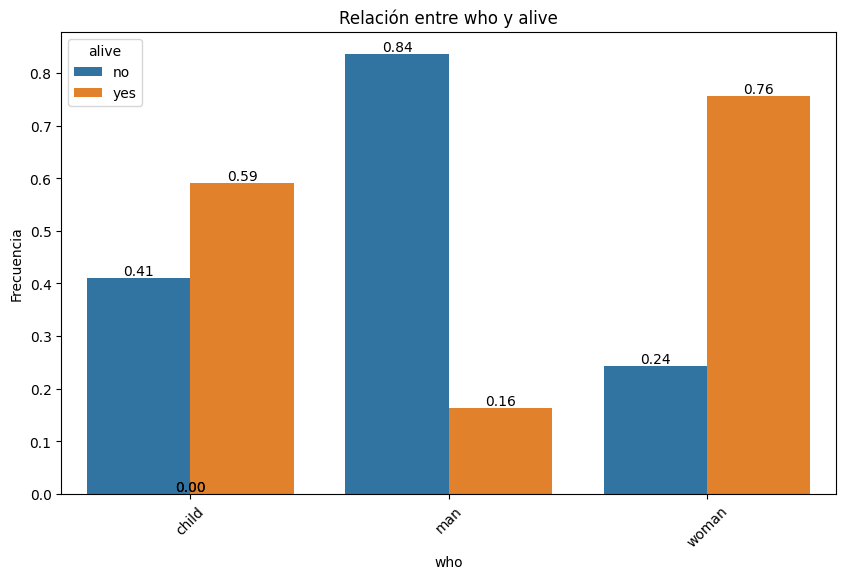

In [46]:
plot_categorical_relationship_fin(df, "who", "alive", relative_freq = True, show_values = True)

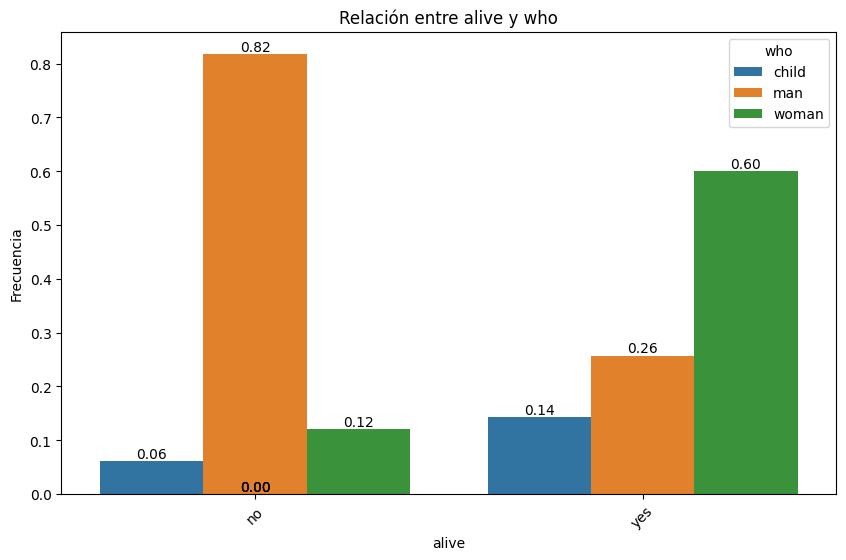

In [48]:
# Puedo dar la vuelta a las variables para ver si se ve mejor (agrupar por alive o por who)

plot_categorical_relationship_fin(df, "alive", "who", relative_freq = True, show_values = True)

In [55]:
# Para comparar la relación entre grupo de edad y sexo (variable who) y supervivencia, empleamos el test chi2

tabla_contingencia = pd.crosstab(df["alive"], df["who"])
chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 283.923050324233
P-Value: 2.2227620817798914e-62
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[ 51.14141414 330.87878788 166.97979798]
 [ 31.85858586 206.12121212 104.02020202]]


> *Claramente podemos rechazar la hipótesis nula de no dependencia y considerar que sí que hay una relación entre el grupo de edad-sexo y la supervivencia estadísticamente significativa. Ser hombre en el titanic fue duro*  

> *Pero otro dato interesante y que podríamos explorar en un potencial EDA es el hecho de que el grupo de los niños sufrió una mortalidad más del doble que el de las mujeres... Mujeres y niños primero,... Por ejemplo un multivariante con clase*

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

In [56]:
# Esto es una clase para comparar una variable directora con otras variables

def tricategorical_analysis(df, directora, otras, relativa = False, muestra_valores = False):
    col_directora = directora
    col_1 = otras[0]
    col_2 = otras[1]
    diccionario_multivariante = {}
    for valor in df[col_directora].unique():
        diccionario_multivariante[valor] = df.loc[df[col_directora] == valor,[col_2,col_1]] 
    for valor,df_datos in diccionario_multivariante.items():
        print(f"Respuesta {valor}:")
        plot_categorical_relationship_fin(df_datos,col_2,col_1, relative_freq= relativa, show_values= muestra_valores)

Respuesta Third:


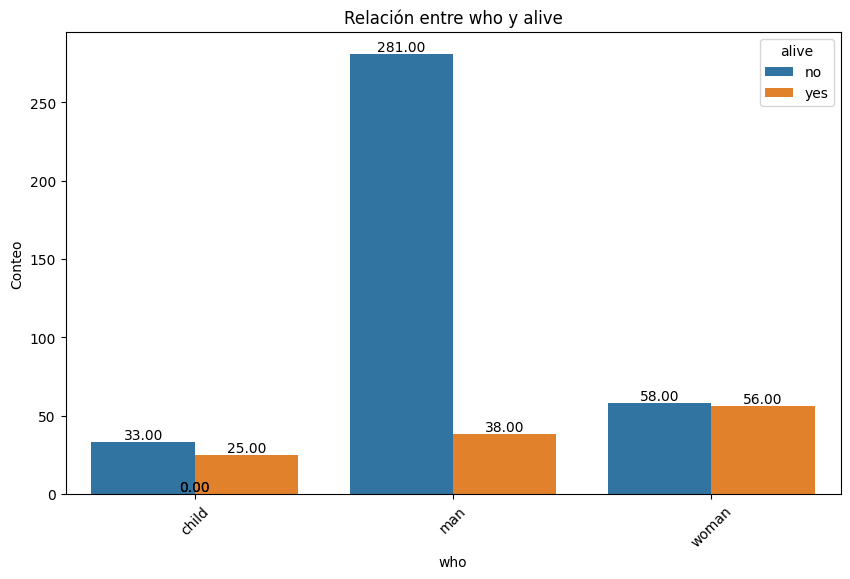

Respuesta First:


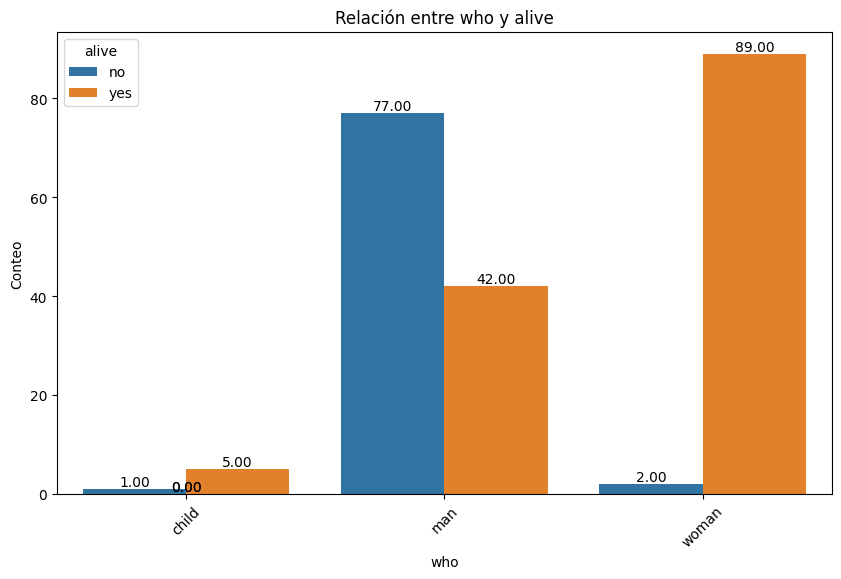

Respuesta Second:


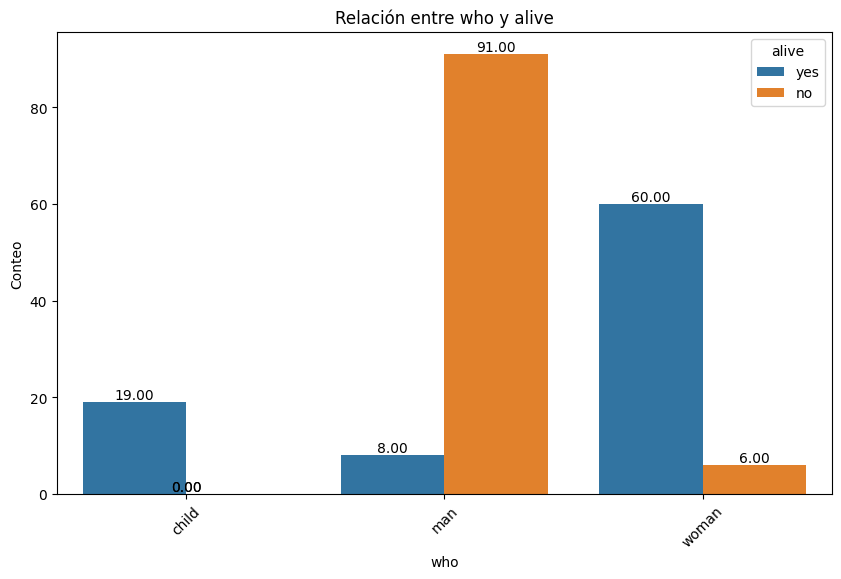

In [58]:
# Aplico la función con class como variables directora...
# Y sobre eso comparo supervivencia y grupos personales. 
# De tal manera que sabré muertes de hombres, mujeres y niños por clase.

tricategorical_analysis(df, "class", ["alive", "who"], muestra_valores = True)

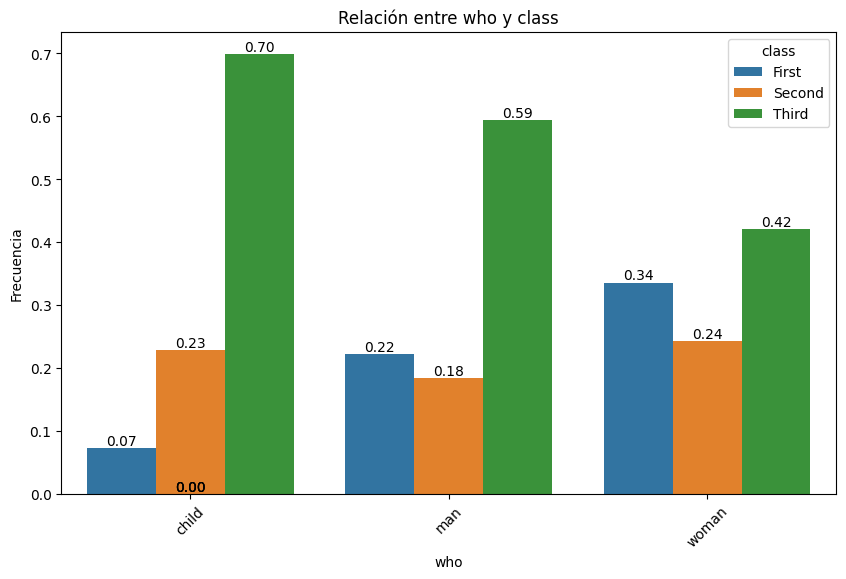

In [ ]:
# También podemos hacer con el gráfico de barras con dos variables. 

plot_categorical_relationship_fin(df, "who", "class", relative_freq = True, show_values = True)

*La explicación de la supervivencia está en la combinación de factores, las mujeres y niños sobrevivieron más en general pero también el factor clase influyó y había muchos más niños en tercera que mujeres en tercera proprocionalmente*

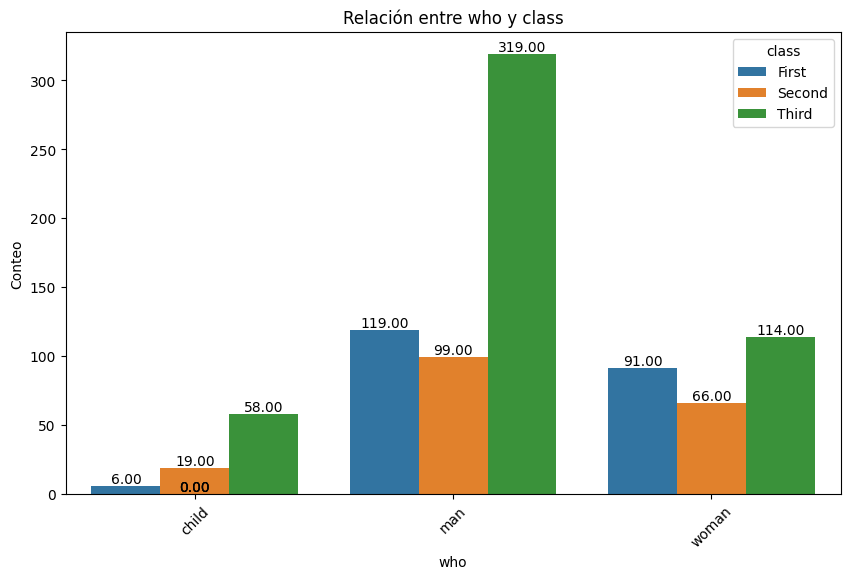

In [61]:
# Aquí lo vemos en términos absolutos

plot_categorical_relationship_fin(df, "who", "class", show_values = True)

*En términos relativos, también fue la primera clase la que mayor ratio de supervivencia muestra, aquí además se ve que hay más porcentaje de supervivientes de segunda que de tercera (47% frente a 24%), y que la diferencia en valores absolutos se debe a la diferencia en términos absolutos entre pasajeros que viajaban en segunda y terecera.*

In [63]:
# Buscamos la relación estadística entre las dos variables: clase y superviviencia

tabla_contingencia = pd.crosstab(df["alive"],df["class"])
chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 102.88898875696056
P-Value: 4.549251711298793e-23
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[133.09090909 113.37373737 302.53535354]
 [ 82.90909091  70.62626263 188.46464646]]


3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

In [75]:
# Aquí estamos viendo una numérica binaria contra una categórica
# Así que directamente nos tiene que venir a la cabeza...
# ... U Mann-Whitney (t-student si la variable tiene distribución normal)

# Miramos distribución con historigrama de edad y ver si aplico U Mann-Whitney o t-student 

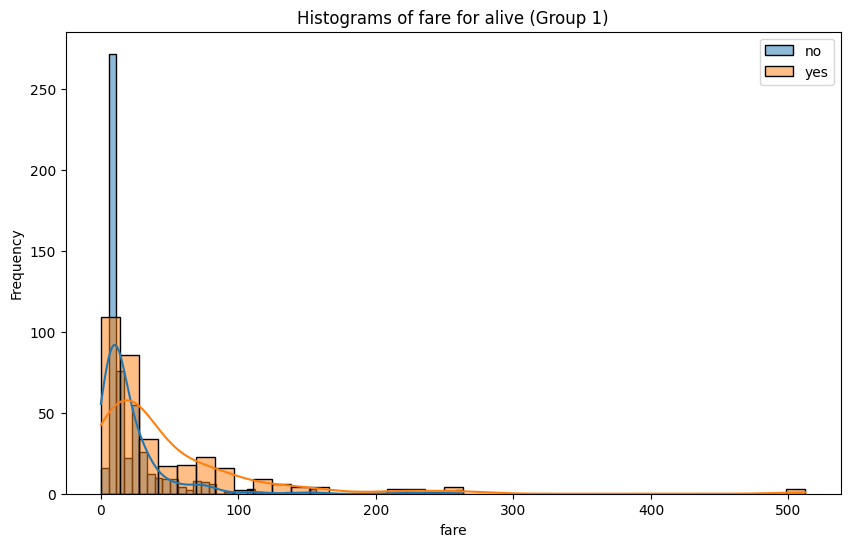

In [71]:
# Plotear los histogramas de supervivencia y salario me permite comparar distribuciones
# Sobre todo por le cruce de funciones de densidad (las curvas de los histogramas)

plot_grouped_histograms(df, "alive", "fare", group_size = 2)

In [73]:
# Separo por grupos de edad y aplico mannwhitneyu

grupo_a = df.loc[df.alive == "yes"]["fare"]
grupo_b = df.loc[df.alive == "no"]["fare"]

u_stat, p_valor = mannwhitneyu(grupo_a, grupo_b)

print("Estadístico U:", u_stat)
print("Valor p:", p_valor)

Estadístico U: 129951.5
Valor p: 4.553477179250237e-22


5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

## #EXTRA: Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino de completar lo que quedó pendiente en el workout y de entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #EXTRA.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

### #EXTRA.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

### #EXTRA.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Reaiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?